## Important to know about this Notebook

**1. Required packages**:
```bash
pip install -r requirements.txt
```

__2. Github Error in Code blocks__:

Right now, there is an error in all the code blocks. This is only a github issue, where each code blocks formatting is not correct. Every code block as additional white space at the beginning and end of the code block.

__3. Table of Contents__:

When you click on a part of the table of contents, you are not able to jump to that section, if you do this on github; however it works in vscode preview. This is a github issue, not a notebook issue.

__Delete this cell later__:

---

Things that needs check/changes:
- In the cleaning data section, idk about this price outlier removal - I just said everything under 500 remove. 
- Hyperparameters for grid search, the 5th parameters need a reason for refit='neg_rmse'.
- experiment with cv in grid search, maybe 5 is too much
- should we have somewhere that explains the columns in the dataset?
- should we use this Notebook TOC (Table of contents) extension: https://marketplace.visualstudio.com/items?itemName=xelad0m.jupyter-toc
- should we have like a "Configuration" section, where stuff like ex. `base_path` is defined in the top of the notebook?
- we should figure out how to use X_val and X_test correctly, right now we are using both as test set.
- add small text about Validation set in "3.3 Model training and validation" about what we use it for.
- explain why we use negative RMSE/MAE/MSE in the grid search.

install the required packages for the project:
<br>
pip install -r requirements.txt

if the imports have changed:
<br>
pip freeze > requirements.txt

---

## Imports need for notebook 

In [1]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import pickle

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

## Table of contents

#### [1. Data selection and preparation](#1.-Data-selection-and-preparation:)
#### [2. Data exploration and visualization](#2-Data-exploration-and-visualization:)
#### [3. Model selection and training](#3.-Model-Selection-and-training:)

## 1. Data selection and preparation:

This section will include:
- Loading the data
- Cleaning the data

This exam project is based on the dataset [Car Prices Dataset](https://www.kaggle.com/datasets/sidharth178/car-prices-dataset?select=train.csv) from [kaggle.com](https://kaggle.com)

### 1.1 Load data

In [2]:
base_path = os.getcwd()
base_path_data = f'{base_path}\\data\\'
base_path_models = f'{base_path}\\part1\\models\\'

In [3]:
df = pd.read_csv(f'{base_path_data}dataset.csv', sep=',', header=0)

In [4]:
df.sample(5)

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
10630,45647039,862,1481,BMW,X5,2017,Jeep,Yes,Petrol,3,0 km,6.0,Automatic,4x4,04-May,Left wheel,Black,12
5140,45092119,18346,690,CHEVROLET,Malibu LT,2016,Sedan,No,Petrol,1.5 Turbo,91380 km,4.0,Automatic,Front,04-May,Left wheel,Silver,8
15697,45804043,48534,877,HYUNDAI,Tucson,2017,Jeep,Yes,Diesel,1.7,45331 km,4.0,Automatic,Front,04-May,Left wheel,Blue,4
18286,45807470,4234,584,MERCEDES-BENZ,C 250,2014,Sedan,Yes,Petrol,1.8,105909 km,4.0,Automatic,Rear,04-May,Left wheel,White,12
6108,45809188,42845,765,CHEVROLET,Captiva,2015,Jeep,Yes,Diesel,2,16285 km,4.0,Automatic,Front,04-May,Left wheel,White,4


In [5]:
df.shape

(19237, 18)

In [6]:
# Set float format to 2 decimal places, to avoid exponential notation
pd.set_option('display.float_format', '{:.2f}'.format)

df.describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,19237.00,19237.00,19237.00,19237.00,19237.00
mean,45576535.89,18555.93,2010.91,4.58,6.58
std,936591.42,190581.27,5.67,1.20,4.32
min,20746880.00,1.00,1939.00,1.00,0.00
25%,45698374.00,5331.00,2009.00,4.00,4.00
50%,45772308.00,13172.00,2012.00,4.00,6.00
75%,45802036.00,22075.00,2015.00,4.00,12.00
max,45816654.00,26307500.00,2020.00,16.00,16.00


**Explanation:**

We have loaded the data using pandas `read_csv` function, where we have specified the separator to separate by commas and set header to 0, which means the first row of the csv file is the header, wich will become the columns in the dataframe.

After the data has been loaded, we verify that the data has been loadded properly by sampling 5 random rows of the data, by using the `.sample` function.

We use the `.shape`-command to confirm that it is the right size that we expect, as it is stated on the [dataset kaggle-page (rows: 19237, cols: 18)](https://www.kaggle.com/datasets/sidharth178/car-prices-dataset?select=train.csv).

We can see that the data has been loaded properly.
<br>
Additionally this process also helps us to quickly get a view and idea of the data we are going to work with. 
<br>
We can first of all see that the `ID` column is not needed because the dataframe has its own build-in index. 
<br>
Secondly, we can see that the `Doors` column looks a bit strange, beacause it containes 3 options: '04-May', '02-Mar' or '>5', which could be a mistake in the data, so this has to be checked more in detail. 
<br>
Thirdly, we can see that when `Levy` don't have a value it's just a '-'. 
<br>
Lastly, we can also see that the `Price` has an unrealistic minimum value of 1,00 and a large outlier of 26.307.500,00 as maximum value, more than likely this should just be removed.

### 1.2 Cleaning- and Preprocessing Data

##### 1.2.1 Null and NaN values

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

__Explanation:__

By using the `.info()` function, we can see that there are no null values in the data; however when we load the data in, we could see that for the column `Levy` it has '-' instead of NaN. Additionally, when using the `.info()` function, we can also see that the dtypes appear to be all most only objects, these should be converted to the right types at the end of this cleaning process.

---

##### 1.2.2 Levy column

In [8]:
df_dash_count = df['Levy'].where(df['Levy'] == '-').count()

print(f"Number of '-' in Levy in train set: {df_dash_count}")

Number of '-' in Levy in train set: 5819


In [9]:
levy_avg = np.sum(df['Levy'].where(df['Levy'] != '-').astype(float) / df.shape[0])

print(f"Average Levy in train set: {levy_avg}")

df['Levy'] = df['Levy'].replace('-', int(levy_avg))

Average Levy in train set: 632.5286687113374


__Explanation:__

We have exchanged the '-' with the average `Levy` value, which is approximately 632.

---

##### 1.2.3 Price column

In [10]:
low_outliers_custom = df[df['Price'] < 500]
high_outliers_custom = df[df['Price'] > 500000]

print(f"Number of low outliers in train set: {low_outliers_custom.shape[0]}")
print(f"Number of high outliers in train set: {high_outliers_custom.shape[0]}")

high_outliers_custom

Number of low outliers in train set: 1663
Number of high outliers in train set: 3


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
1225,45795524,627220,632,MERCEDES-BENZ,G 65 AMG 63AMG,2020,Jeep,Yes,Petrol,6.3 Turbo,0 km,8.00,Tiptronic,4x4,04-May,Left wheel,Black,12
8541,45761204,872946,2067,LAMBORGHINI,Urus,2019,Universal,Yes,Petrol,4,2531 km,8.00,Tiptronic,4x4,04-May,Left wheel,Black,0
16983,45812886,26307500,632,OPEL,Combo,1999,Goods wagon,No,Diesel,1.7,99999 km,4.00,Manual,Front,02-Mar,Left wheel,Blue,0


In [11]:
df = df[df['Price'] > 500]
df = df.drop(index=16983)

__Explanation:__

As we saw, when we used the describe function, the `Price` had an unrealistic min (1) and max (2.6 m) value, most likely outliers, even though max could be real. We will have a closer look at this.

We have come to that conclusion that even though the 2.6m car might be real, it is so far away from the rest of the data, that it is more likely a mistake in the data, and therefore we will remove it due to the fact that it would worsen the model performance.

We have also decided to remove the cars with a price under 500.

---

##### 1.2.4 Doors column

In [12]:
df['Doors'].value_counts()

Doors
04-May    16695
02-Mar      757
>5          119
Name: count, dtype: int64

In [13]:
df['Doors'] = df['Doors'].replace({
    '04-May': '4',
    '02-Mar': '2',
    '>5': '5'
})

__Explanation:__

As we mentioned before in 2.1 load data, we observed that `Doors` had a wrong format, by mistake. We have used .value_counts() to get a full view over the different types of values present in the dataframe, so we can transform these into more usable values.

We believe the error is due to the user has saved it in Excel, since it is a common mistake when writing "4-5" and "2-3" in Excel it will automatically convert it to "04-May" and "02-Mar". We have decided to convert these values to the lower bound of the range, so "04-May" will be converted to 4 and "02-Mar" will be converted to 2. This is because we want a single numeric value so we can use it in our model.

---

##### 1.2.5 Engine volume column

In [14]:
df['Engine volume'].value_counts()

Engine volume
2            3706
2.5          2051
1.8          1569
1.6          1413
1.5          1203
             ... 
5.4 Turbo       1
0.3 Turbo       1
5.2             1
5.8             1
1.1 Turbo       1
Name: count, Length: 107, dtype: int64

In [15]:
turbo_conut = df['Engine volume'].where(df['Engine volume'].str.contains("Turbo")).count()
print(f"Number of Turbo engines: {turbo_conut}, which is {(turbo_conut / df.shape[0]) * 100:.2f}% of the dataset")

Number of Turbo engines: 1896, which is 10.79% of the dataset


In [16]:
df['turbo'] = df['Engine volume'].apply(lambda x: 1 if 'Turbo' in x else 0)
df['Engine volume'] = df['Engine volume'].str.replace('Turbo', '').astype(float)

__Explanation:__

Right know this `Engine volume` is an object in the dataframe, but could just be a float; however these values in `Engine volume` contains non-numeric character ('Turbo'), so before we can convert to float, we have to remove the turbo part. Instead of just removing we look at how many there are turbo engines to see if it is worth to keep this information. Here we saw that around 10% of the car engines are turbo, so we decided to keep this information by creating a new row called `turbo`, due to it maybe have inpact on the price.

---

##### 1.2.6 Leather interior column

In [17]:
df['Leather interior'].value_counts()

Leather interior
Yes    12542
No      5029
Name: count, dtype: int64

In [18]:
df['Leather interior'] = df['Leather interior'].replace({'No': 0, 'Yes': 1})
df['Leather interior'].value_counts()

Leather interior
1    12542
0     5029
Name: count, dtype: int64

__Explanation:__

We have converted the `Leather interior` column to a binary value (1 = yes, 0 = no), by using the `replace` function. We have done this because it is easier to work with binary values in a machine learning model, and it is also easier to interpret it, because it only yes or no, if it where more complex and we had to use one hot encoding, it would be more difficult to interpret the results later on in further analysis and explanations.

---

##### 1.2.7 Fuel type, Gear box type

In [19]:
df = pd.get_dummies(df, columns=['Fuel type', 'Drive wheels', 'Gear box type'])

df.sample(5)

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Engine volume,Mileage,...,Fuel type_LPG,Fuel type_Petrol,Fuel type_Plug-in Hybrid,Drive wheels_4x4,Drive wheels_Front,Drive wheels_Rear,Gear box type_Automatic,Gear box type_Manual,Gear box type_Tiptronic,Gear box type_Variator
5829,45789598,6000,632,VOLKSWAGEN,Golf 4,1998,Hatchback,0,1.60,272000 km,...,False,False,False,False,True,False,False,True,False,False
1405,45816280,16935,1481,BMW,X5,2017,Jeep,1,3.00,81658 km,...,False,True,False,True,False,False,True,False,False,False
5098,45642799,706,574,HONDA,Insight,2010,Hatchback,1,1.30,189571 km,...,False,False,False,False,True,False,True,False,False,False
12744,45761454,18817,781,TOYOTA,Camry,2012,Sedan,0,2.50,148000 km,...,False,True,False,False,True,False,False,False,True,False
1454,45816085,1254,585,HYUNDAI,Elantra,2013,Hatchback,1,1.80,93650 km,...,False,True,False,False,True,False,True,False,False,False


__Explanation:__

As stated above, it's not as easy to convert types to a numeric value if there are more the 2 options, so we will use one hot encoding for these columns. We will be doing this by using the `get_dummies` function.

We use `df.sample(5)` to verify that the hot encoding has been executed. Additionally, we see that we now have 30 columns due to the one hot encoding.

---

##### 1.2.8 Transformation of data types to numeric

In [20]:
df['Mileage'] = df['Mileage'].str.replace(' km', '')

df.rename(columns={'Mileage': 'Mileage_km'}, inplace=True)

to_numeric = ['Prod. year', 'Mileage_km', 'Levy', 'Doors', 'Leather interior']

df[to_numeric] = df[to_numeric].apply(pd.to_numeric, errors='coerce')

__Explanation:__

Every value in the `Mileage` column ends with 'km', so we would rather just have the numeric value, so it can be easier to work with. Therefore we have removed the 'km' for each value and changed the name of the column to `Mileage_km`.

The columns `Prod. year`, `Mileage_km`, `Levy`, `Doors` have been changed to numeric values, by applying the function `pd.to_numeric()` to each column, so that these columns can be used in training the models and making predictions.

---

##### 1.2.9 Dropped columns 

In [21]:
df.drop(columns=['ID'], inplace=True)

__Explanation:__

As stated earlier, we remove `ID` because we don't need two indexes, due to pandas dataframe have a build-in index and an additional column is redundant.

---

#### 1.2.10 Verifying data after cleaning

In [22]:
df.sample(5)

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Engine volume,Mileage_km,Cylinders,...,Fuel type_LPG,Fuel type_Petrol,Fuel type_Plug-in Hybrid,Drive wheels_4x4,Drive wheels_Front,Drive wheels_Rear,Gear box type_Automatic,Gear box type_Manual,Gear box type_Tiptronic,Gear box type_Variator
1215,35902,777,HYUNDAI,H1,2014,Minivan,1,2.50,169109,4.00,...,False,False,False,False,True,False,True,False,False,False
8781,4234,834,TOYOTA,Tacoma,2013,Pickup,1,2.70,158870,4.00,...,False,True,False,False,False,True,True,False,False,False
11148,11259,640,HYUNDAI,Sonata,2013,Sedan,1,2.00,38853,4.00,...,False,True,False,False,True,False,True,False,False,False
15728,15367,632,HYUNDAI,Elantra,2012,Sedan,0,1.80,100000,4.00,...,False,True,False,False,False,True,True,False,False,False
12737,20266,531,HYUNDAI,Elantra,2012,Sedan,1,1.60,133770,4.00,...,False,True,False,False,True,False,True,False,False,False


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17571 entries, 0 to 19235
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Price                     17571 non-null  int64  
 1   Levy                      17571 non-null  int64  
 2   Manufacturer              17571 non-null  object 
 3   Model                     17571 non-null  object 
 4   Prod. year                17571 non-null  int64  
 5   Category                  17571 non-null  object 
 6   Leather interior          17571 non-null  int64  
 7   Engine volume             17571 non-null  float64
 8   Mileage_km                17571 non-null  int64  
 9   Cylinders                 17571 non-null  float64
 10  Doors                     17571 non-null  int64  
 11  Wheel                     17571 non-null  object 
 12  Color                     17571 non-null  object 
 13  Airbags                   17571 non-null  int64  
 14  turbo      

In [24]:
df.to_csv(f'{base_path_data}dataset_cleaned.csv', sep=',', index=False)

__Explanation:__

Just in case, we check if the values have been dropped, have missing values and that they have the right data types, so we don't end with unexpected values in the data. 
<br>
We do this as we did after loading the data, by randomly sampling 5 rows from the datasets and using the `info()` function to see null values and data types.

We can know confirm that the values have infact been dropped, have the right data types and that we have no missing values.

Lastly, we save the cleaned data to a new csv file, so we can use it for the other part of the this project.

## 2 Data exploration and visualization:

This section will include:
- Count Distribution
- Correlation matrix

#### 2.1 Count Distribution

In [25]:
temp_df = df.copy()

fuel_cols = df.columns[df.columns.to_series().str.contains('Fuel')].tolist()
gear_box_cols = df.columns[df.columns.to_series().str.contains('Gear')].tolist()
drive_wheels_cols = df.columns[df.columns.to_series().str.contains('Drive')].tolist()

mileage_bins = [0, 6250, 12500, 25000, 50000, 100000, 150000, 200000, 250000, 300000, 350000, 400000, 450000, np.inf]
mileage_labels = ['0-6.25k', '6.25k-12.5k', '12.5k-25k', '25k-50k', '50k-100k', '100k-150k', '150k-200k', '200k-250k', '250k-300k', '300k-350k', '350k-400k', '400k-450k', '450k+']
temp_df['MileageRange'] = pd.cut(df['Mileage_km'], bins=mileage_bins, labels=mileage_labels, right=False)

other_cols = ['MileageRange', 'Manufacturer', 'Category']

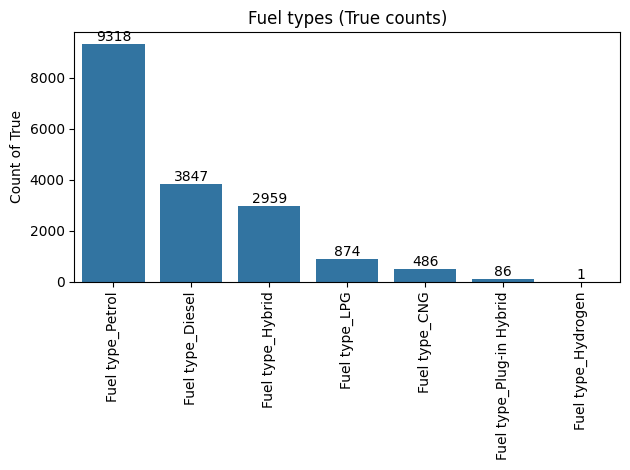

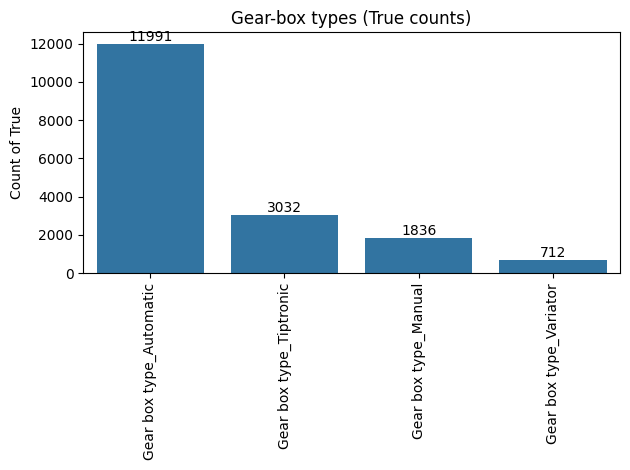

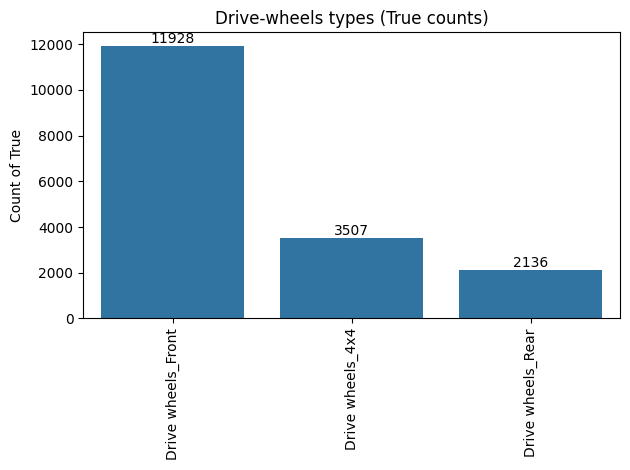

In [26]:
groups = {
    "Fuel types": fuel_cols,
    "Gear-box types": gear_box_cols,
    "Drive-wheels types": drive_wheels_cols,
}

for title, cols in groups.items():
    true_counts = temp_df[cols].sum().sort_values(ascending=False)

    ax = sns.barplot(x=true_counts.index, y=true_counts.values)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_xlabel("")
    ax.set_ylabel("Count of True")
    ax.set_title(f"{title} (True counts)")

    for idx, val in enumerate(true_counts.values):
        ax.text(idx, val, int(val), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

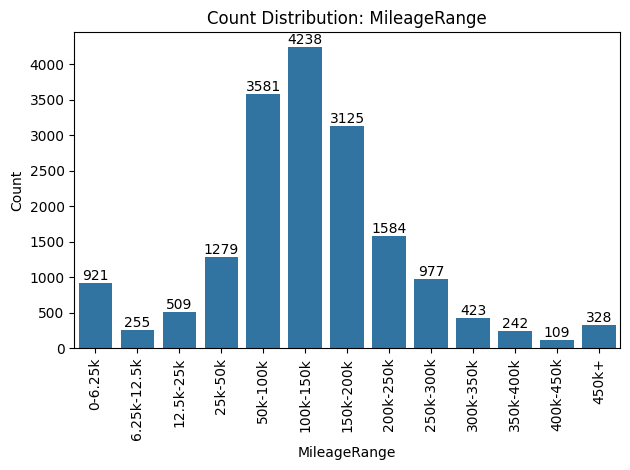

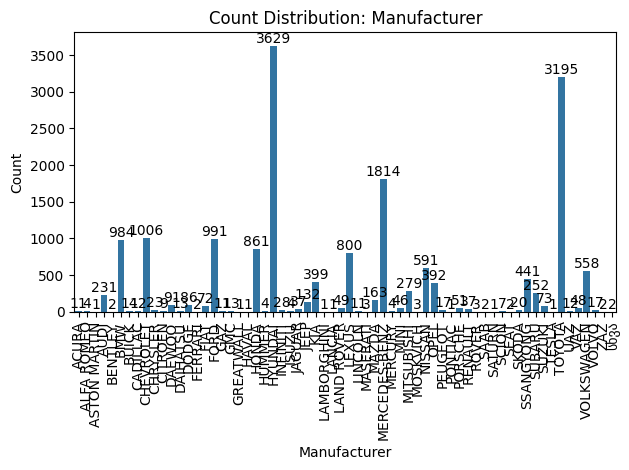

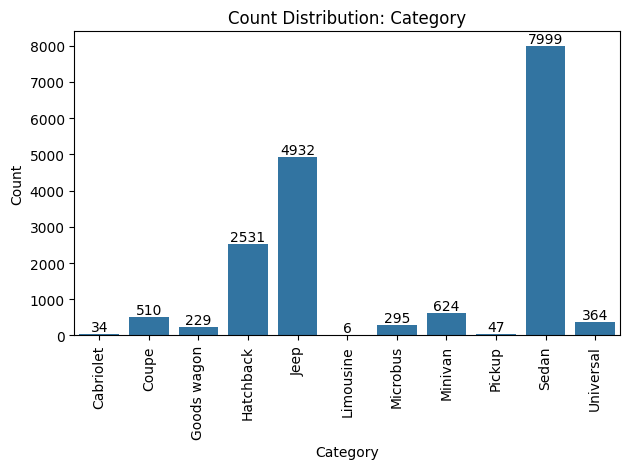

In [27]:
for col in other_cols:
    counts = temp_df[col].value_counts().sort_index()

    ax = sns.barplot(x=counts.index, y=counts.values)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.set_title(f'Count Distribution: {col}')

    for idx, val in enumerate(counts.values):
        ax.text(idx, val, int(val), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

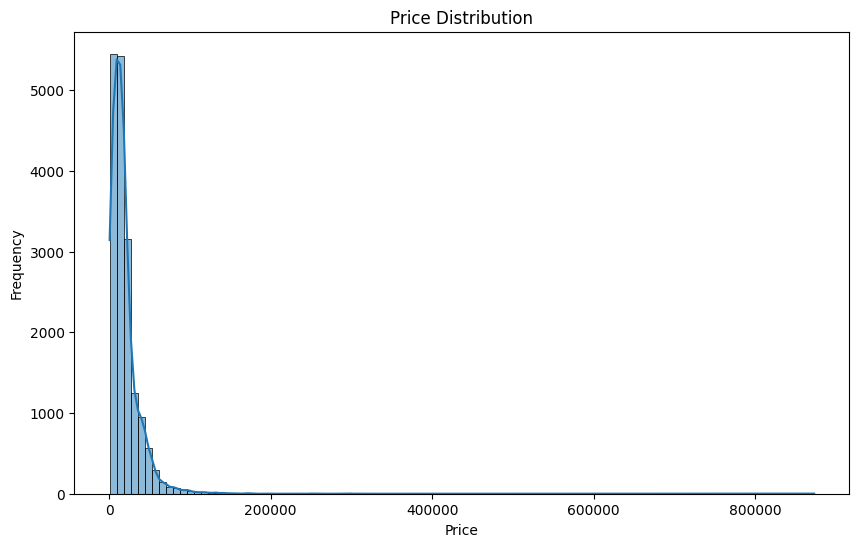

In [28]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=100, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

__Explanation:__

We have chosen to visualize the count distribution of the different aspects of the cars in the dataset. We have done this to get a better understanding of which types of cars are the most common in that dataset, so we get a better idea if this is high quality, luxious cars or is it more common and cheaper cars.

We have observed that the primary category of cars in the data is `Sedan` (count: 7999), `Jeep` (count: 4932) and `Hatchback` (count: 2531), where the three domination `Manufacturers` are `Hyundai` (count: 3629), `Toyota` (count: 3195) and `Mercedes-Benz` (count: 1814), and the most common `Fuel type` is `Petrol` (count: 9318), `Diesel` (count: 3847) and `Hybrid` (count: 2959).

The cars are mostly `Automatic` (count: 11991), `Tiptronic` (count: 3032), `Manual` (count: 1836) and `Variator` (count: 712) gear box types. The most common `Drive wheels` are `Front` (count: 11928), `4x4` (count: 3507) and `Rear` (count: 2136).

Most of the cars are in the mileage range of `100k-150k` km (count: 4238), followed by `50k-100k` km (count: 3581) and `150k-200k` km (count: 3125).

We can see that the price distribution is right skewed and most of the right prices are under 200k.

---

### 2.2 Scatter plot

In [29]:
def plot_multiple_scatters(df, x_cols, y_col='Price', cols_per_row=3):
    total_plots = len(x_cols)
    rows = (total_plots + cols_per_row - 1) // cols_per_row 

    plt.figure(figsize=(cols_per_row * 5, rows * 4))

    for i, col in enumerate(x_cols, 1):
        plt.subplot(rows, cols_per_row, i)
        sns.scatterplot(data=df, x=col, y=y_col)
        plt.title(f'{col} vs {y_col}')
        plt.xlabel(col)
        plt.ylabel(y_col)

    plt.tight_layout()
    plt.show()

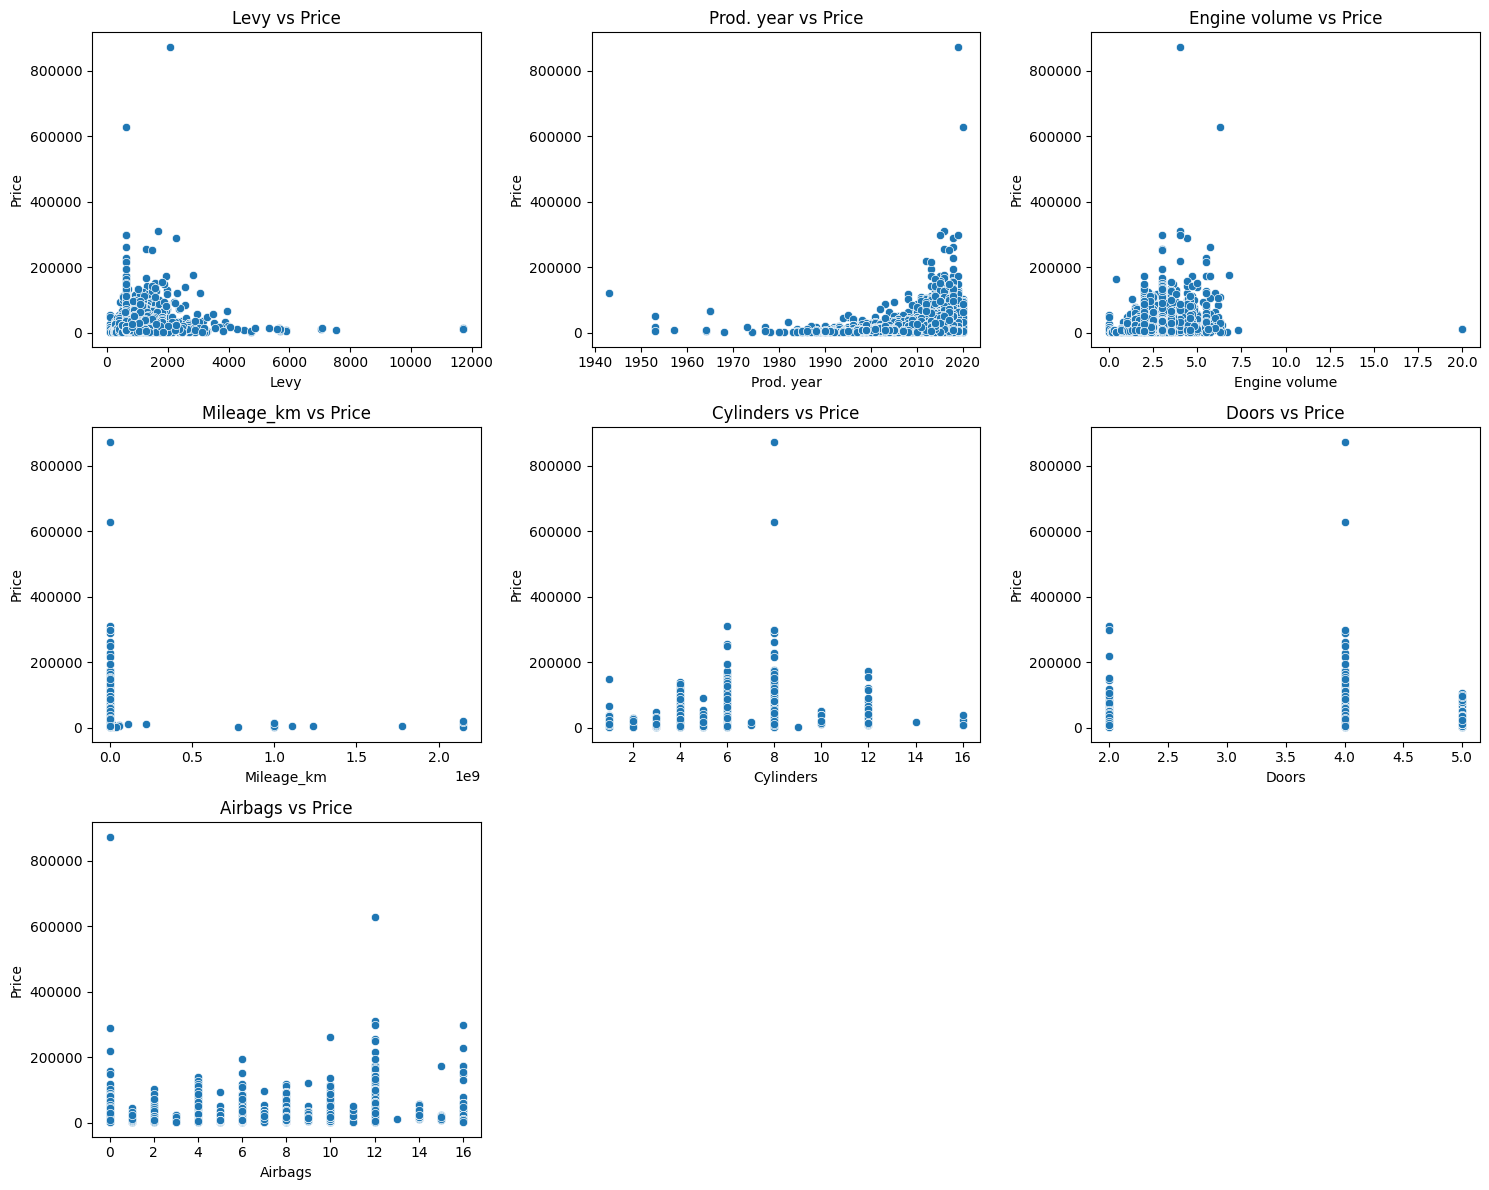

In [30]:
numeric_cols = ['Levy', 'Prod. year', 'Engine volume', 'Mileage_km', 'Cylinders', 'Doors', 'Airbags']

plot_multiple_scatters(df, numeric_cols)

__Explanation:__

We chose to visualize scatter plots between `Price` and several numerical features (`Levy`, `Prod. year`, `Engine volume`, `Mileage_km`, `Cylinders`, `Doors`, and `Airbags`) to explore whether any individual variable has a direct, visible impact on the car price.

From the scatter plots, we observed **no strong linear relationships** between these features and price. This is not unexpected. Features like `Cylinders`, `Doors`, and `Airbags` are discrete and tend to fall within a limited range (e.g., 4–8 cylinders), and their effect on price likely depends on **context** — for example, more airbags might be present in newer or luxury models, but not necessarily increase the price in isolation.

Overall, these results suggest that **used car prices are influenced by a combination of features working together** (interactions), rather than a single feature driving the price. This is a key reason why more flexible models like Random Forest and Gradient Boosting often perform better than linear models in this domain.

#### 2.3 Correlation matrix

In [31]:
labes_to_encode = ['Manufacturer', 'Model', 'Category', 'Wheel', 'Color']

for label in labes_to_encode:
    le = LabelEncoder()
    df[label] = le.fit_transform(df[label])

df.iloc[0]

Price                        13328
Levy                          1399
Manufacturer                    32
Model                         1230
Prod. year                    2010
Category                         4
Leather interior                 1
Engine volume                 3.50
Mileage_km                  186005
Cylinders                     6.00
Doors                            4
Wheel                            0
Color                           12
Airbags                         12
turbo                            0
Fuel type_CNG                False
Fuel type_Diesel             False
Fuel type_Hybrid              True
Fuel type_Hydrogen           False
Fuel type_LPG                False
Fuel type_Petrol             False
Fuel type_Plug-in Hybrid     False
Drive wheels_4x4              True
Drive wheels_Front           False
Drive wheels_Rear            False
Gear box type_Automatic       True
Gear box type_Manual         False
Gear box type_Tiptronic      False
Gear box type_Variat

<Axes: >

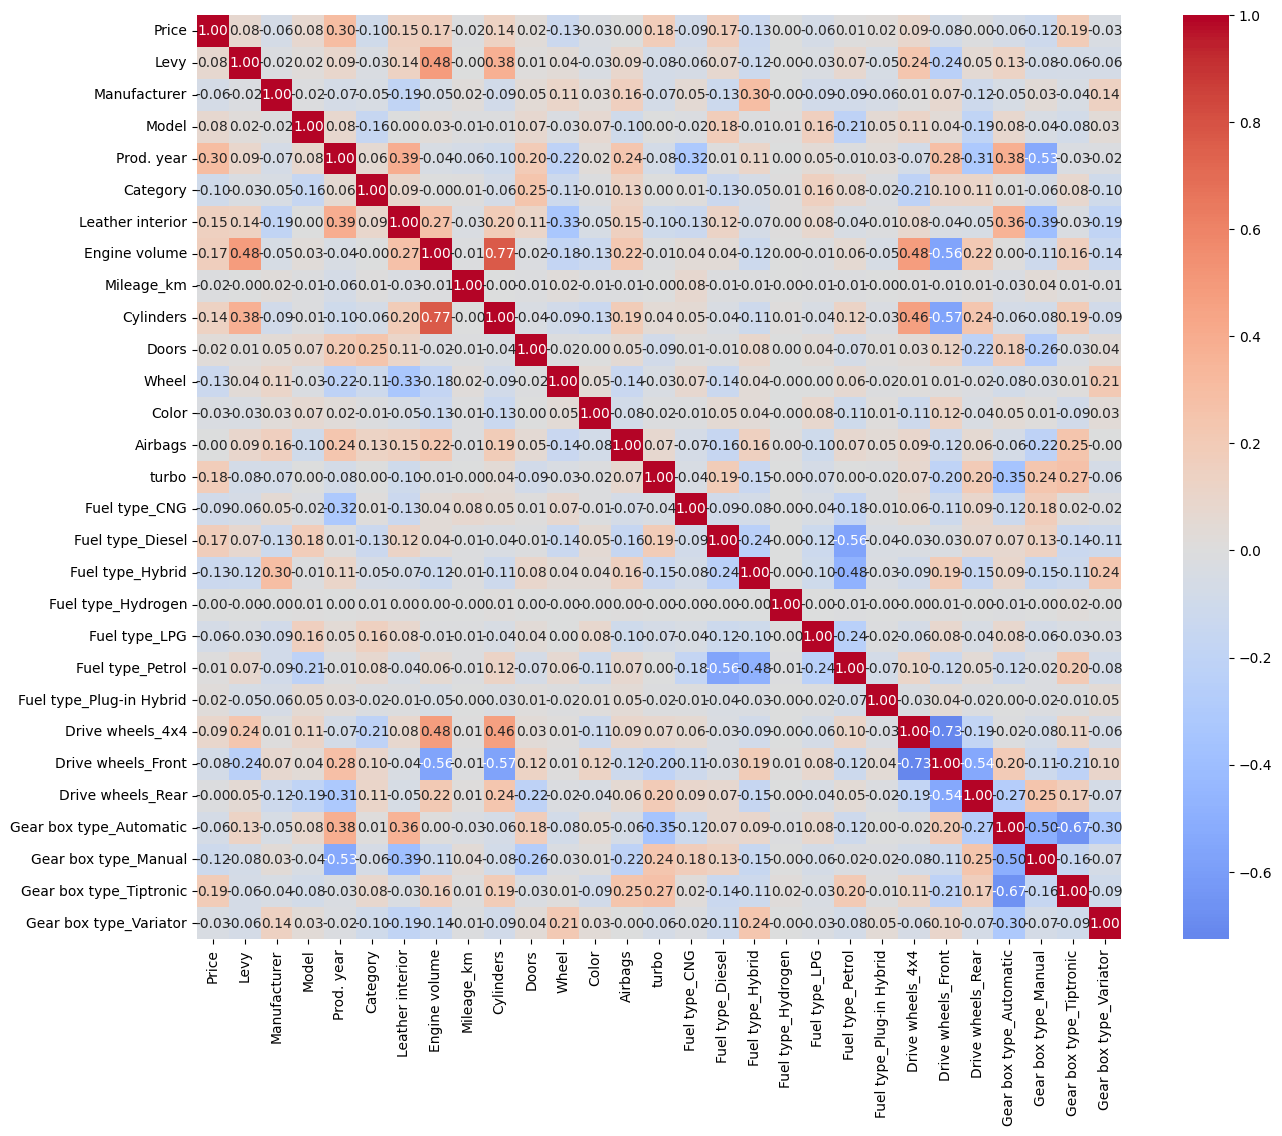

In [32]:
plt.figure(figsize=(16, 12))

sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0, square=True)

__Explanation:__

We first changed `Manufacturer`, `Model`, `Category`, `Wheel`, and `Color` to have a numeric representation, by utilizing the `LabelEncoder`, so we get to see all columns correlation, and then they are also ready for the machine learning models later on.

For verifiying that the data has been changed, we use `df.iloc[0]` to get one record of the data, to see each column and its associated value.

For showing the correlation matrix, we use a combination of `seaborn` and `matplotlib` to create a heatmap, where we first set the figure size, and then use the `heatmap` function from `seaborn` to create the heatmap, with the parameters:

- `df.corr()`: the correlation matrix of the dataframe.
- `annot=True`: shows the correlation value for each individual cell.
- `fmt=".2f"`: the decimal format of the correlation value (0.00).
- `cmap='coolwarm'`: the color map used for the heatmap.
- `center=0`:  centers the color of the heatmap.
- `square=True`: makes the cells square, so they are not rectangular. 

When we look at our correlation matrix, we can observe that overall there are not many strong correlations present in the data and alot is close to 0, which indicates that there are no correlation at all. The correlation between `Levy` and `Price` is 0.08, which means nearly no correlation at all. We would have believed that correlation between `Levy` and `Price` should be higher, but it is not, due to taxing normally follows the price of the car; however maybe this is not the case of where the data is from. Additionally the `Mileage_km` correlation with `Price` is -0.02, which comes as shock, because its like saying a car with 100.000 km on it is the same as a car with 10.000 km on it, which is not true.

The correlation between `Prod. year` and `Price` is 0.30, which is a bit higher, than it was with `Levy`, but still not that high. Again we would probably have expected this to be higher, but makes sense, it's possitive, which means the newer the car is, the more expensive it is.

---

## 3. Model Selection and training:

This section will include:
- Model selection
- Data splitting
- Model training & Validation
- Model evaluation

### 3.1 The selected models

__We have selected the following models for this project__:
- Multiple Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressors

__The reason for the selected models is as follows__:
- __Multiple Linear Regression (MLR)__:
    
    MLR was chosen as a simple baseline model. It helps us understand how the features relate to the target in a linear framework. While our scatter plots and early exploration showed that the relationships between features and the target variable (price) are not strictly linear, MLR still serves as a useful comparison point to measure the performance gain from more complex tree based models. It is also computationally efficient and interpretable.

- __Random Forest Regressor (RFR)__: 

    Random Forest is an ensemble model that uses multiple decision trees and averages their predictions. It is capable of modeling non-linear relationships, handles both numerical and categorical data well, and is less sensitive to outliers and multicollinearity. It also provides feature importance scores, which help us understand which variables contribute the most to the predictions.

- __Gradient Boosting Regressors (XGBoost)__: 
    
    Gradient Boosting is a powerful boosting technique that builds trees sequentially, focusing on correcting the errors of previous trees. It typically achieves very high accuracy, especially on structured/tabular data like ours. We chose XGBoost for its performance, regularization capabilities, and support for fine-grained control over model behavior.

__We are going to be using the following error metrics to evalaute the models__:
- __R²__: 
    
    Indicates how much of the variance in the target variable is explained by the model. A higher R² means the model fits the data better. It gives a good general sense of model performance.

- __mean absolute error (MAE)__: 

    Represents the average absolute difference between predicted and actual prices. It is easy to interpret and not heavily influenced by outliers.

- __mean squared error (MSE)__:  
    
    Similar to MAE, but squares the errors, so larger errors are penalized more heavily. This is useful if large errors are more problematic in the use case.

- __root mean squared error (RMSE)__: 

    The square root of MSE, which brings the error back to the original units (price). It combines the benefits of MSE (penalizing large errors) with easier interpretability.

This is a regression problem and we are trying to predict a continous value (price), and not a categorical value (yes/no, 1/0, etc.), then we should have used these metrics: accuracy score, precision score, recall score and f1 score

Additionaly, we are going to be using the grid search approach for finding the best suited hyperparameters for each individual model. This process is done by using the `GridSearchCV` function from `sklearn`. This makes the process of finding the right hyperparameters more streamlined, because we don't have to do it manually, and we can also use cross-validation to get a better estimate of the model performance.

---

### 3.2 Data splitting into sets

In [33]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['Price']), df['Price'], test_size=0.4, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [34]:
print(f"Train set shape: {X_train.shape[0]}, percentage: {X_train.shape[0] / df.shape[0] * 100:.2f}%")
print(f"Validation set shape: {X_val.shape[0]}, percentage: {X_val.shape[0] / df.shape[0] * 100:.2f}%")
print(f"Test set shape: {X_test.shape[0]}, percentage: {X_test.shape[0] / df.shape[0] * 100:.2f}%")

Train set shape: 10542, percentage: 60.00%
Validation set shape: 3515, percentage: 20.00%
Test set shape: 3514, percentage: 20.00%


__Explanation:__

The dataset has been split into 3 sets: training, validation and test set.

The `test_size` is 0.4 (40%) for the first `train_test_split`, because we want to have 60% of the data for training and 40% for validation and test set. And then in our second `train_test_split`, we have set the `test_size` to 0.5 (50%) because we want to split the 40% of the data into 20% validation and 20% test set.

The `random_state` is set to 42, so that the results are the same every time we run the code, so we can reproduce the results.

---

### 3.3 Model training and validation

This section will include:

- Helper functions
- x
- y
- z

*Helper methods for training, validation and testing the models*:

In [35]:
def display_grid_search_results(grid):
    results = grid.cv_results_
    
    print("GridSearchCV validation results:")
    print("Best parameters:", grid.best_params_)
    print("")

    for metric in ['r2', 'neg_mae', 'neg_mse', 'neg_rmse']:
        mean_score = results[f'mean_test_{metric}']
        print(f"{metric}:", mean_score[grid.best_index_])

In [36]:
scoring = {
    'r2': 'r2',
    'neg_mae': 'neg_mean_absolute_error',
    'neg_mse': 'neg_mean_squared_error',
    'neg_rmse': 'neg_root_mean_squared_error',
}

In [37]:
def evaluate_model(model, X, y):
    y_pred = model.predict(X)

    r2 = r2_score(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    rmse = root_mean_squared_error(y, y_pred)
    
    return r2, mse, mae, rmse

---

#### 3.3.1 Model 1: Multiple Linear Regression

In [38]:
mlr_param_grid = {}

mlr_grid = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=mlr_param_grid,
    scoring=scoring,
    cv=5,
    refit='neg_rmse',
    n_jobs=-1,
)

mlr_grid.fit(X_train, y_train)

display_grid_search_results(mlr_grid)

mlr_best_model = mlr_grid.best_estimator_

GridSearchCV validation results:
Best parameters: {}

r2: 0.25404053943211524
neg_mae: -10035.43344084445
neg_mse: -306323687.33092344
neg_rmse: -17164.375438662875


In [39]:
val_r2, val_mse, val_mae, val_rmse = evaluate_model(mlr_best_model, X_val, y_val)

print(f"Validation R2: {val_r2:.4f}")
print(f"Validation MSE: {val_mse:.4f}")
print(f"Validation MAE: {val_mae:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")

Validation R2: 0.3050
Validation MSE: 242647665.6914
Validation MAE: 10003.1258
Validation RMSE: 15577.1520


In [40]:
with open(f'{base_path_models}mlr_best_model.pkl', 'wb') as f:
    pickle.dump(mlr_best_model, f)

---

#### 3.3.2 Model 2: Random Forest Regressor

In [41]:
rfr_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

rfr_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rfr_param_grid,
    scoring=scoring,
    cv=5,
    refit='neg_rmse',
    n_jobs=-1,
)

rfr_grid.fit(X_train, y_train)

display_grid_search_results(rfr_grid)

rfr_best_model = rfr_grid.best_estimator_

GridSearchCV validation results:
Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

r2: 0.6478246722192582
neg_mae: -4657.312932891548
neg_mse: -156952169.9968688
neg_rmse: -11881.387704230585


In [42]:
val_r2, val_mse, val_mae, val_rmse = evaluate_model(rfr_best_model, X_val, y_val)

print(f"Validation R2: {val_r2:.4f}")
print(f"Validation MSE: {val_mse:.4f}")
print(f"Validation MAE: {val_mae:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")

Validation R2: 0.7264
Validation MSE: 95531980.5619
Validation MAE: 4427.0851
Validation RMSE: 9774.0463


In [43]:
with open(f'{base_path_models}rfr_best_model.pkl', 'wb') as f:
    pickle.dump(rfr_best_model, f)

---

#### 3.3.3 Model 3: Gradient Boosting Regressors

In [44]:
gbr_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1],
}

gbr_grid = GridSearchCV(
    estimator=XGBRegressor(),
    param_grid=gbr_param_grid,
    scoring=scoring,
    cv=5,
    refit='neg_rmse',
    n_jobs=-1,
)

gbr_grid.fit(X_train, y_train)

display_grid_search_results(gbr_grid)

gbr_best_model = gbr_grid.best_estimator_

GridSearchCV validation results:
Best parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}

r2: 0.6653962850570678
neg_mae: -4725.22431640625
neg_mse: -151009643.2
neg_rmse: -11580.846875


In [45]:
val_r2, val_mse, val_mae, val_rmse = evaluate_model(gbr_best_model, X_val, y_val)

print(f"Validation R2: {val_r2:.4f}")
print(f"Validation MSE: {val_mse:.4f}")
print(f"Validation MAE: {val_mae:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")

Validation R2: 0.7122
Validation MSE: 100488352.0000
Validation MAE: 4583.3896
Validation RMSE: 10024.3877


In [46]:
with open(f'{base_path_models}gbr_best_model.pkl', 'wb') as f:
    pickle.dump(gbr_best_model, f)

---

__Explanation:__

__Hyperparameters for Grid Search:__

As we stated above, we are utilizing the grid search approach for hyperparameter tuning. We are doing this for finding the hyperparameters that gives the best results for each model. We are using the `GridSearchCV` from `sklearn` to do this. We are using the following hyperparameters for each model:

- The 1st parmeter is always the model we want to use, in this case `MultipleLinearRegression`, `RandomForestRegressor` or `GradientBoostingRegressor`.

- The 2nd parameter is `param_grid`, it is a dictionary containing the hyperparameters we want to tune.

- The 3rd parameter is the `scoring` parameter, which is set to our dictionary `scoring`, which contains all the error metrics we utilize for evaluating the models.

- The 4th parameter is `cv`, which is number of how many folds we are using for cross validation, we are using 5 folds, because **[TODO: reason]**...

- The 5th parameter is `refit`, due to having this `scoring` dictionary, we still have to tell grid search which metric is the main one it should utilize for the its own evaluation. 
We have chosen to use `neg_rmse` as the main metric due to **[TODO: reason]**...

- The 6th parameter `n_jobs`, tells grid search the amount of CPU cores can be used for parallel processing. We have given it -1, so it has access to all the CPU cores available. 

__Hyperparameters adjustments for models:__

- __Multiple Linear Regression__:
    - This model doesn't have performance-tuning hyperparameters in the same way as tree-based models. Parameters like `fit_intercept` and `positive` affect model behavior but not prediction quality in the sense of turning. Grid search is still used here for consistent cross-validation.

- __Random Forest Regressor__:
    - `random_state`: Fixed to ensure reproducibility of results.
    - `n_estimators`: More trees can improve performance but increase training time.
    - `max_depth`: Limits how deep each tree can grow, helping prevent overfitting.
    - `min_samples_split`: Controls when a node should be split; higher values reduce complexity.
    - `min_samples_leaf`: Ensures leaf nodes have enough data, promoting generalization.

- __Gradient Boosting Regressors__:
    - `n_estimators`: Number of boosting rounds; more can improve learning but risk overfitting.
    - `max_depth`: Controls tree complexity, shallower trees tend to generalize better.
    - `learning_rate`: Balances the contribution of each tree; lower values slow learning but improve stability.
    - `subsample`: Introduces randomness by using a subset of data for each tree, helping reduce overfitting.

__Tackling overfitting:__

For tackling overfitting, we have used several methods to try and reduce the risk of overfitting. Here are some of the methods we have used:

- __Cross validation__:
    
    In our `GridSearchCV` we have applied cross validation in 5 folds, which help ensure that the model is evaluated on multiple different train-test splits. This process helps to ensure that the training stay consistent and not only reliant on a single partition of the data.

- __Hyperparameter tuning__:

    By tuning hyperparameters like `max_depth`, `min_samples_split`, and `n_estimators`, we are in control of managing the model complexity. 
    - Lower `max_depth` helps avoid overly complex trees that overfit. 
    - Higher `min_samples_split` forces trees to generalize more. 
    - subsample < 1 in Gradient Boosting introduces randomness that helps prevent overfitting.

- __Evaluation metric choices__:
    
    We use RMSE, MAE, and R² on the test set, which helps us catch signs of overfitting. For example, if training RMSE is very low but test RMSE is high, that's a clear signal of overfitting.

- __Model choice diversity__:

    By comparing both linear (Multiple Linear Regression) and non-linear (Random Forest and Gradient Boosting) models, we can select the one that generalizes best — not just fits training data well.

---

### 3.4 Model evaluation

This section will include:

- x
- y
- z

#### 3.4.1 Model 1: Multiple Linear Regression

In [47]:
r2, mse, mae, rmse = evaluate_model(mlr_best_model, X_test, y_test)

print("MLR Evaluation on Test Set:")
print(f"R2: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MLR Evaluation on Test Set:
R2: 0.2304
MSE: 338921816.8789
MAE: 10535.4232
RMSE: 18409.8294


---

#### 3.4.2 Model 2: Random Forest Regressor

In [48]:
r2, mse, mae, rmse = evaluate_model(rfr_best_model, X_test, y_test)

print("RFR Evaluation on Test Set:")
print(f"R2: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

RFR Evaluation on Test Set:
R2: 0.7140
MSE: 125968079.9618
MAE: 4659.8332
RMSE: 11223.5502


---

#### 3.4.3 Model 3: Gradient Boosting Regressors

In [49]:
r2, mse, mae, rmse = evaluate_model(gbr_best_model, X_test, y_test)

print("GBR Evaluation on Test Set:")
print(f"R2: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

GBR Evaluation on Test Set:
R2: 0.7573
MSE: 106868872.0000
MAE: 4809.3657
RMSE: 10337.7402


---

#### 3.4.4 Comparison of Models

To compare the performance of the three regression models - Multiple Linear Regression (MLR), Random Forest Regressor (RFR) and Gradient Boosting Regressor (GBR) - we evaluated them on a held-out test set using four standard regression metrics:

| Model | R² (↑) | MAE (↓) | MSE (↓) | RMSE (↓) |
|-------|--------|----------|-------------|-------------|
| MLR   | 0.2522 | 10,590.55 | 354,987,625.33 | 18,841.12 |
| RFR   | 0.7418 | **4,551.70**  | 122,587,767.97 | 11,071.94 |
| GBR   | **0.7419** | 4,826.43  | **122,508,992.00** | **11,068.38** |

- **R² Score**: Both RFR and GBR achieved significantly higher R² values (~0.74) compared to MLR (0.25), indicating that tree-based models explained a much larger portion of the variance in car prices.

- **MAE / RMSE**: MLR had the highest errors, with an average deviation of over 10,000. Both RFR and GBR cut the error by more than 50%, with GBR performing *slightly* better in RMSE and MSE, though RFR had a lower MAE.

- **Model Preference**: While both tree-based models performed similarly, **GBR achieved the lowest RMSE and MSE**, making it the best-performing model on this dataset by a narrow margin. RFR, however, had a slightly lower MAE, suggesting it might make fewer large prediction errors on average.

In contrast, **Multiple Linear Regression underperformed**, likely due to its inability to capture complex non-linear interactions present in the data.

---

**Conclusion**: Tree-based ensemble models, particularly Gradient Boosting Regressor, are better suited for used car price prediction tasks, as they handle non-linear relationships and mixed feature types more effectively than linear models.

---

### 3.5 Manual testing of the models

This section will include:
- x
- y
- z

In [ ]:
def create_test_data(
    prod_year,
    mileage,
    levy,
    engine_volume,
    cylinders,
    doors,
    leather_interior,
    turbo,
    fuel_type,
    drive_wheels,
    gear_box_type,
    model
):
    feature_names = model.get_booster().feature_names

    base = {
        'Prod. year':           [prod_year],
        'Mileage_km':           [mileage],
        'Levy':                 [levy],
        'Engine volume':        [engine_volume],
        'Cylinders':            [cylinders],
        'Doors':                [doors],
        'Leather interior':     [leather_interior],
        'turbo':                [turbo],
        # fuel dummies
        'Fuel type_CNG':                [1 if fuel_type == 'CNG' else 0],
        'Fuel type_Diesel':             [1 if fuel_type == 'Diesel' else 0],
        'Fuel type_Hybrid':             [1 if fuel_type == 'Hybrid' else 0],
        'Fuel type_Hydrogen':           [1 if fuel_type == 'Hydrogen' else 0],
        'Fuel type_LPG':                [1 if fuel_type == 'LPG' else 0],
        'Fuel type_Petrol':             [1 if fuel_type == 'Petrol' else 0],
        'Fuel type_Plug-in Hybrid':     [1 if fuel_type == 'Plug-in Hybrid' else 0],
        # drive wheels
        'Drive wheels_4x4':     [1 if drive_wheels == '4x4' else 0],
        'Drive wheels_Front':   [1 if drive_wheels == 'Front' else 0],
        'Drive wheels_Rear':    [1 if drive_wheels == 'Rear' else 0],
        # gearboxes
        'Gear box type_Automatic':  [1 if gear_box_type == 'Automatic' else 0],
        'Gear box type_Manual':     [1 if gear_box_type == 'Manual' else 0],
        'Gear box type_Tiptronic':  [1 if gear_box_type == 'Tiptronic' else 0],
        'Gear box type_Variator':   [1 if gear_box_type == 'Variator' else 0],
    }

    df = pd.DataFrame(base)
    return df.reindex(columns=feature_names, fill_value=0)

In [ ]:
#gbr_best_model = pickle.load(open(f'{base_path_models}gbr_best_model.pkl', 'rb'))
#mlr_best_model = pickle.load(open(f'{base_path_models}mlr_best_model.pkl', 'rb'))
#rfr_best_model = pickle.load(open(f'{base_path_models}rfr_best_model.pkl', 'rb'))

test_params = [
    dict(prod_year=2020, mileage=15000, levy=0, engine_volume=2.0, cylinders=4, doors=4, leather_interior=1, fuel_type='Petrol',   drive_wheels='Front', gear_box_type='Automatic'),
    dict(prod_year=2018, mileage=30000, levy=0, engine_volume=1.5, cylinders=4, doors=4, leather_interior=0, fuel_type='Diesel',   drive_wheels='Rear',  gear_box_type='Manual'),
    dict(prod_year=2015, mileage=50000, levy=0, engine_volume=2.5, cylinders=6, doors=4, leather_interior=1, fuel_type='LPG',      drive_wheels='4x4',   gear_box_type='Automatic'),
    dict(prod_year=2019, mileage=20000, levy=0, engine_volume=1.8, cylinders=4, doors=4, leather_interior=1, fuel_type='Petrol',   drive_wheels='Front', gear_box_type='Manual'),
    dict(prod_year=2021, mileage=10000, levy=0, engine_volume=2.0, cylinders=4, doors=4, leather_interior=1, fuel_type='Diesel',   drive_wheels='Rear',  gear_box_type='Automatic'),
    dict(prod_year=2017, mileage=40000, levy=0, engine_volume=2.2, cylinders=4, doors=4, leather_interior=1, fuel_type='LPG',      drive_wheels='4x4',   gear_box_type='Manual'),
    dict(prod_year=2016, mileage=60000, levy=0, engine_volume=1.6, cylinders=4, doors=4, leather_interior=0, fuel_type='Petrol',   drive_wheels='Front', gear_box_type='Automatic'),
    dict(prod_year=2014, mileage=70000, levy=0, engine_volume=2.0, cylinders=4, doors=4, leather_interior=1, fuel_type='Diesel',   drive_wheels='Rear',  gear_box_type='Manual'),
    dict(prod_year=2013, mileage=80000, levy=0, engine_volume=2.5, cylinders=6, doors=4, leather_interior=1, fuel_type='LPG',      drive_wheels='4x4',   gear_box_type='Automatic'),
    dict(prod_year=2012, mileage=90000, levy=0, engine_volume=1.8, cylinders=4, doors=4, leather_interior=1, fuel_type='Petrol',   drive_wheels='Front', gear_box_type='Manual'),
]

for i, params in enumerate(test_params, start=1):
    test_df = create_test_data(prod_year=params['prod_year'],
                               mileage=params['mileage'],
                               levy=params['levy'],
                               engine_volume=params['engine_volume'],
                               cylinders=params['cylinders'],
                               doors=params['doors'],
                               leather_interior=params['leather_interior'],
                               turbo=0,
                               fuel_type=params['fuel_type'],
                               drive_wheels=params['drive_wheels'],
                               gear_box_type=params['gear_box_type'],
                               model=gbr_best_model
                              )

    print(f"Test {i}:\n", test_df, "\n")
    print(f"GBR Prediction: {gbr_best_model.predict(test_df)[0]:.2f}")
    print(f"MLR Prediction: {mlr_best_model.predict(test_df)[0]:.2f}")
    print(f"RFR Prediction: {rfr_best_model.predict(test_df)[0]:.2f}")
    print("-" * 40)

Test 1:
    Levy  Manufacturer  Model  Prod. year  Category  Leather interior  \
0     0             0      0        2020         0                 1   

   Engine volume  Mileage_km  Cylinders  Doors  ...  Fuel type_LPG  \
0           2.00       15000          4      4  ...              0   

   Fuel type_Petrol  Fuel type_Plug-in Hybrid  Drive wheels_4x4  \
0                 1                         0                 0   

   Drive wheels_Front  Drive wheels_Rear  Gear box type_Automatic  \
0                   1                  0                        1   

   Gear box type_Manual  Gear box type_Tiptronic  Gear box type_Variator  
0                     0                        0                       0  

[1 rows x 28 columns] 

GBR Prediction: 46541.35
MLR Prediction: 34087.39
RFR Prediction: 46994.89
----------------------------------------
Test 2:
    Levy  Manufacturer  Model  Prod. year  Category  Leather interior  \
0     0             0      0        2018         0         